In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

Images shape: (10, 64, 64, 3)
Labels shape: (10,)


(-0.5, 63.5, 63.5, -0.5)

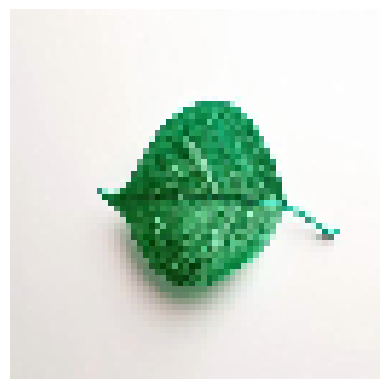

In [4]:
data_path = "plantdataset"   # <-- this is your folder name
categories = ["Class1", "Class2"] # <--this is th sub folder

data = [] #<--empty space to store the images
labels = [] #<--empty space to store the label 0 and 1
img_size = 64

for category in categories:
    folder_path = os.path.join(data_path, category)
    label = categories.index(category)  # Class1 = 0, Class2 = 1
    
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        
        img = cv2.imread(img_path)          # read image
        img = cv2.resize(img, (img_size, img_size))  # resize
        
        data.append(img)     # store image
        labels.append(label) # store label

X = np.array(data) / 255.0
y = np.array(labels)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

plt.imshow(X[0])
plt.axis("off")

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 8
Testing images: 2


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()//adding layer one by one
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3))) //it detect the edges and shapes from image
model.add(MaxPooling2D((2,2)))// it reduce the size of the image
model.add(Flatten())//it convert features in single line list
model.add(Dense(64, activation='relu'))//it  predict the class
model.add(Dense(1, activation='sigmoid'))//it give final output

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 30752)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │       1,968,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,969,153 (7.51 MB)

 Trainable params: 1,969,153 (7.51 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3750 - loss: 0.7087 - val_accuracy: 0.5000 - val_loss: 0.7063
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.6250 - loss: 0.4799 - val_accuracy: 0.5000 - val_loss: 0.4369
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 1.0000 - loss: 0.2963 - val_accuracy: 1.0000 - val_loss: 0.2277
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 1.0000 - loss: 0.0941 - val_accuracy: 1.0000 - val_loss: 0.2656
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 1.0000 - loss: 0.0453 - val_accuracy: 1.0000 - val_loss: 0.1527
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 1.0000 - loss: 0.0171 - val_accuracy: 1.0000 - val_loss: 0.0560
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0173
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.

In [9]:
test_img = cv2.imread("test.jpg")
test_img = cv2.resize(test_img, (64,64))
test_img = test_img / 255.0
test_img = np.reshape(test_img, (1,64,64,3))

prediction = model.predict(test_img)

if prediction[0][0] > 0.5:
    print("Predicted: class2")
else:
    print("Predicted: class1")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: class2
